# ASSIGNMENT 10 — Comparing GAN and VAE Using My Experimental Results

**Name:** Aarush C S  
**Assignment:** 10 — Comparing GAN and VAE Using Experimental Results

### Objective

In this assignment, I compare the results of the **DCGAN from Assignment 4** and the **VAE from Assignment 8**.

I am using the same type of experiments that I performed earlier instead of making a comparison only from theory. I will compare the models using generated images, training behaviour, and a few simple observations.

The main points I will compare are:

- Image sharpness
- Diversity
- Realism
- Training stability
- Ease of controlling the output
- Risk of mode collapse
- Typical applications

At the end, I will decide which model I would prefer for **synthetic training data** and which one I would prefer for **anomaly detection**.

## 1. Models Used in My Previous Assignments

For this comparison, I am reusing the two models from my earlier assignments.

### Assignment 4 — DCGAN

My Assignment 4 used a **Deep Convolutional GAN (DCGAN)** on the **Fashion-MNIST** dataset.

Important settings from my experiment:

- Dataset: Fashion-MNIST
- Training images: 60,000
- Image size: 28 × 28 grayscale
- Latent dimension: 100
- Batch size: 128
- Epochs: 30
- Learning rate: 0.0002
- Optimizer: Adam
- Generator output activation: Tanh

The generator creates clothing images from random noise, while the discriminator tries to distinguish generated images from real Fashion-MNIST images.

### Assignment 8 — VAE

My Assignment 8 used a **Variational Autoencoder** on the **MNIST handwritten digit dataset**.

Important settings from my experiment:

- Dataset: MNIST
- Training images: 60,000
- Image size: 28 × 28 grayscale
- Latent dimension: 2
- Batch size: 128
- Epochs: 20
- Learning rate: 0.001
- Optimizer: Adam

The 2-dimensional latent space was used so that I could visualise how the VAE organizes the digit representations.

## 2. Importing the Required Libraries

I am using PyTorch for the DCGAN because that is how I implemented Assignment 4, and TensorFlow/Keras for the VAE because that is how I implemented Assignment 8.

I also use NumPy, Pandas and Matplotlib for storing results, calculating simple supporting measurements and displaying the generated images.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)
print("PyTorch device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
TensorFlow: 2.21.0
PyTorch device: cuda
GPU: Tesla T4


## 3. Loading the Same Datasets Used in My Previous Assignments

For the GAN, I need Fashion-MNIST normalized approximately to **[-1, 1]** because the generator uses `Tanh` at its output.

For the VAE, I use MNIST normalized to **[0, 1]** because the decoder uses a sigmoid output and binary cross-entropy reconstruction loss.

This keeps the preprocessing consistent with my previous experiments.

In [2]:
# -----------------------------
# Fashion-MNIST for Assignment 4 GAN
# -----------------------------
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

gan_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=gan_transform
)

gan_loader = DataLoader(
    gan_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

# -----------------------------
# MNIST for Assignment 8 VAE
# -----------------------------
vae_transform = transforms.ToTensor()

vae_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=vae_transform
)

vae_loader = DataLoader(
    vae_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

print("Fashion-MNIST training images:", len(gan_dataset))
print("MNIST training images:", len(vae_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.3MB/s]
100%|██████████| 9.91M/9.91M [00:02<00:00, 4.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.50MB/s]

Fashion-MNIST training images: 60000
MNIST training images: 60000


## 4. Recreating  Assignment 4 DCGAN

I am using the same basic DCGAN structure from Assignment 4 instead of changing the architecture for this comparison.

The generator starts with a 100-dimensional random vector and gradually converts it into a 28 × 28 image.

The discriminator does the opposite: it receives an image and tries to decide whether it is real or generated.

This is important because I want the comparison to represent the models I actually studied and trained earlier.

In [3]:
LATENT_DIM_GAN = 100
GAN_EPOCHS = 30
GAN_LR = 0.0002
GAN_BETA1 = 0.5

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator(LATENT_DIM_GAN).to(device)
D = Discriminator().to(device)

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

criterion_gan = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=GAN_LR,
    betas=(GAN_BETA1, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=GAN_LR,
    betas=(GAN_BETA1, 0.999)
)

fixed_noise = torch.randn(
    8, LATENT_DIM_GAN, 1, 1, device=device
)

generator = G
discriminator = D

print("DCGAN architecture matched to Assignment 4.")


DCGAN architecture matched to Assignment 4.


## 5. Training the DCGAN

The GAN is trained in two steps inside every batch.

First, I train the discriminator using both real and generated images.

Then I train the generator. Its goal is to produce images that the discriminator classifies as real.

I save the average generator and discriminator losses after every epoch so I can also look at the training behaviour later.

In [4]:
generator_losses = []
discriminator_losses = []

for epoch in range(1, GAN_EPOCHS + 1):
    running_g = 0.0
    running_d = 0.0

    for real_images, _ in gan_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Train Discriminator
        optimizer_D.zero_grad(set_to_none=True)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        real_output = discriminator(real_images)
        loss_d_real = criterion_gan(real_output, real_labels)

        noise = torch.randn(
            batch_size, LATENT_DIM_GAN, 1, 1, device=device
        )
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        loss_d_fake = criterion_gan(fake_output, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad(set_to_none=True)

        output = discriminator(fake_images)
        loss_g = criterion_gan(output, real_labels)

        loss_g.backward()
        optimizer_G.step()

        running_d += loss_d.item()
        running_g += loss_g.item()

    avg_d = running_d / len(gan_loader)
    avg_g = running_g / len(gan_loader)

    discriminator_losses.append(avg_d)
    generator_losses.append(avg_g)

    print(
        f"Epoch [{epoch:02d}/{GAN_EPOCHS}] | "
        f"D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}"
    )

print("DCGAN training complete.")


Epoch [01/30] | D Loss: 0.7506 | G Loss: 1.6022
Epoch [02/30] | D Loss: 0.8498 | G Loss: 1.4711
Epoch [03/30] | D Loss: 1.0453 | G Loss: 1.2195
Epoch [04/30] | D Loss: 1.0506 | G Loss: 1.1855
Epoch [05/30] | D Loss: 1.0878 | G Loss: 1.1611
Epoch [06/30] | D Loss: 1.1210 | G Loss: 1.1314
Epoch [07/30] | D Loss: 1.1431 | G Loss: 1.0980
Epoch [08/30] | D Loss: 1.1585 | G Loss: 1.0868
Epoch [09/30] | D Loss: 1.1729 | G Loss: 1.0797
Epoch [10/30] | D Loss: 1.1962 | G Loss: 1.0754
Epoch [11/30] | D Loss: 1.1788 | G Loss: 1.0527
Epoch [12/30] | D Loss: 1.1985 | G Loss: 1.0663
Epoch [13/30] | D Loss: 1.1977 | G Loss: 1.0497
Epoch [14/30] | D Loss: 1.1991 | G Loss: 1.0483
Epoch [15/30] | D Loss: 1.2028 | G Loss: 1.0430
Epoch [16/30] | D Loss: 1.2081 | G Loss: 1.0451
Epoch [17/30] | D Loss: 1.2088 | G Loss: 1.0367
Epoch [18/30] | D Loss: 1.2114 | G Loss: 1.0342
Epoch [19/30] | D Loss: 1.2144 | G Loss: 1.0284
Epoch [20/30] | D Loss: 1.2238 | G Loss: 1.0361
Epoch [21/30] | D Loss: 1.2161 | G Loss:

## 6. Looking at GAN Training Behaviour

I plotted both losses together because GAN training is different from normal supervised training.

I do not expect both losses to simply decrease smoothly. Instead, the generator and discriminator compete with each other. I use this graph as supporting evidence when discussing training stability.

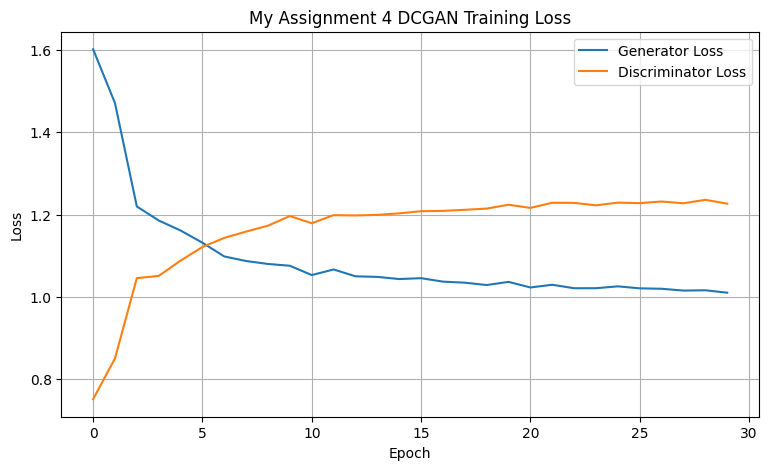

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("My Assignment 4 DCGAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## 7. Eight Images Generated by My GAN

Here I generate eight samples from the trained generator using fixed random noise.

Using fixed noise makes the result easier to compare because the same latent inputs can be used whenever I rerun the final generation cell.

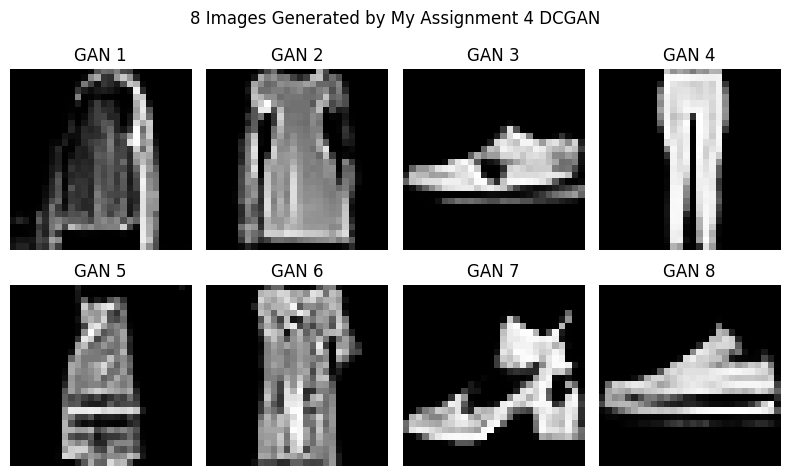

In [6]:
generator.eval()

with torch.no_grad():
    gan_generated = generator(fixed_noise).cpu()

generator.train()

fig, axes = plt.subplots(2, 4, figsize=(8, 5))

for i, ax in enumerate(axes.flatten()):
    image = (gan_generated[i] + 1) / 2
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"GAN {i+1}")
    ax.axis("off")

plt.suptitle("8 Images Generated by My Assignment 4 DCGAN")
plt.tight_layout()
plt.show()

## 8. Recreating My Assignment 8 VAE

My Assignment 8 used a 2-dimensional latent space.

The encoder does not directly produce one fixed latent vector. It produces a **mean** and **log variance**. The reparameterization step then samples a latent vector from that distribution.

The decoder converts the 2-dimensional latent vector back into a 28 × 28 MNIST image.

I kept the same Dense-layer structure from Assignment 8 so that the comparison is based on my previous experiment.

In [7]:
LATENT_DIM_VAE = 2
VAE_EPOCHS = 20
VAE_LR = 0.001

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

print("Training data:", x_train_flat.shape)
print("Testing data:", x_test_flat.shape)

# Encoder
encoder_inputs = keras.Input(shape=(784,), name="encoder_input")

x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_inputs)
x = layers.Dense(64, activation="relu", name="encoder_dense_2")(x)

z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var],
    name="encoder"
)

# Sampling layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

sampling_layer = Sampling()

# Decoder
latent_inputs = keras.Input(shape=(LATENT_DIM_VAE,), name="decoder_input")

x = layers.Dense(64, activation="relu", name="decoder_dense_1")(latent_inputs)
x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
decoder_outputs = layers.Dense(784, activation="sigmoid", name="decoder_output")(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

print("VAE architecture created.")
print("Latent dimension:", LATENT_DIM_VAE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 784)
Testing data: (10000, 784)
VAE architecture created.
Latent dimension: 2


## 9. Training the VAE

The VAE uses two important parts in its loss:

1. **Reconstruction loss** — checks how well the decoded image matches the original image.
2. **KL-divergence loss** — keeps the learned latent distribution close to a standard normal distribution.

I track both losses separately because Assignment 8 was also focused on understanding the latent space and the effect of these losses.

In [8]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, sampling_layer, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampling_layer = sampling_layer

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = self.sampling_layer([z_mean, z_log_var])
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampling_layer([z_mean, z_log_var])
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            ) * 784

            kl_loss = -0.5 * (
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }


vae = VAE(encoder, decoder, sampling_layer)
vae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=VAE_LR)
)

history = vae.fit(
    x_train_flat,
    epochs=VAE_EPOCHS,
    batch_size=128,
    shuffle=True,
    verbose=1
)

recon_loss_history = history.history["reconstruction_loss"]
kl_loss_history = history.history["kl_loss"]
total_loss_history = history.history["loss"]

print("Training complete.")
print("Final reconstruction loss:", recon_loss_history[-1])
print("Final KL loss:", kl_loss_history[-1])
print("Final total loss:", total_loss_history[-1])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - kl_loss: 5.2581 - loss: 199.1135 - reconstruction_loss: 193.8556
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.6279 - loss: 171.7804 - reconstruction_loss: 167.1525
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.9456 - loss: 165.3103 - reconstruction_loss: 160.3647
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.1295 - loss: 161.6508 - reconstruction_loss: 156.5213
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3239 - loss: 158.7459 - reconstruction_loss: 153.4221
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.5110 - loss: 156.2444 - reconstruction_loss: 150.7334
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6494 - loss: 154.3117 - reconstruction_loss: 148.6622
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.7757 - loss: 152.8006 - reconstruction_loss: 147.0249
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/s

## 10. Looking at VAE Training Behaviour

The graph below shows how the reconstruction and KL-divergence components changed during training.

Compared with the GAN, the VAE has a more direct optimisation objective. This makes its training behaviour easier to follow.

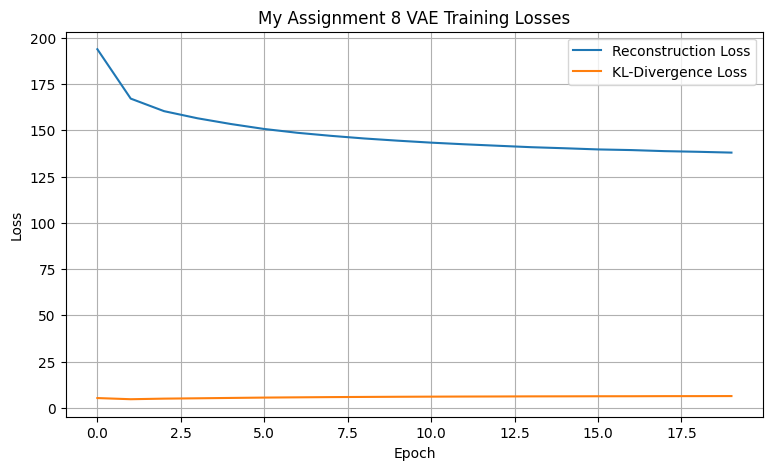

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(recon_loss_history, label="Reconstruction Loss")
plt.plot(kl_loss_history, label="KL-Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("My Assignment 8 VAE Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 11. Visualising My VAE Latent Space

One of the main parts of Assignment 8 was the 2D latent space.

I use the encoder to obtain the mean latent representation of the test images and plot the points using their digit labels. This helps me see how the VAE has organised the different digits.

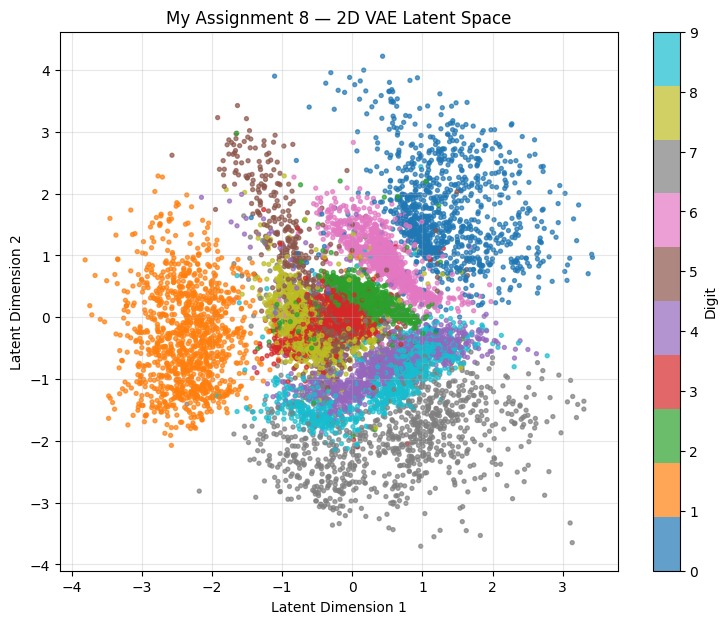

In [10]:
z_mean_test, z_log_var_test = encoder.predict(
    x_test_flat,
    batch_size=128,
    verbose=0
)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("My Assignment 8 — 2D VAE Latent Space")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Eight Images Generated by My VAE

For the final VAE comparison, I sample eight different points from the 2D latent space and pass them through the decoder.

This is different from the GAN because I can directly choose the coordinates in the VAE latent space and observe how the generated digits change.

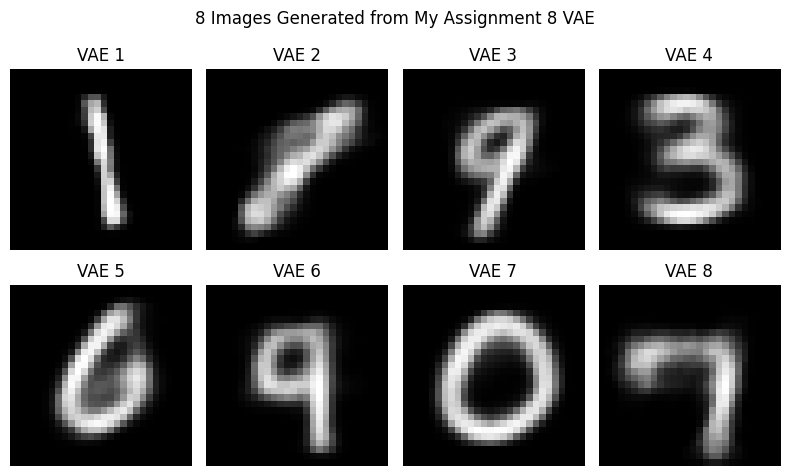

In [11]:
vae_latent_points = np.array([
    [-2.5, -2.0],
    [-1.5,  1.0],
    [-0.5, -1.5],
    [ 0.0,  0.0],
    [ 0.5,  1.5],
    [ 1.0, -0.5],
    [ 1.8,  1.5],
    [ 2.5, -1.0]
], dtype=np.float32)

vae_generated = decoder.predict(
    vae_latent_points,
    verbose=0
).reshape(8, 28, 28)

fig, axes = plt.subplots(2, 4, figsize=(8, 5))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(vae_generated[i], cmap="gray")
    ax.set_title(f"VAE {i+1}")
    ax.axis("off")

plt.suptitle("8 Images Generated from My Assignment 8 VAE")
plt.tight_layout()
plt.show()

## 13. Simple Supporting Measurements

The assignment mainly asks for a visual comparison, so I do not treat these numbers as a final scientific evaluation.

I calculate two simple proxies:

- **Sharpness proxy:** average squared pixel changes in horizontal and vertical directions.
- **Diversity proxy:** average pairwise pixel difference between generated images.

These measurements are only supporting evidence. In particular, a higher sharpness score does not automatically mean an image is more realistic.

In [12]:
def sharpness_proxy(images):
    values = []

    for image in images:
        image = image.squeeze().numpy()

        dx = np.diff(image, axis=1)
        dy = np.diff(image, axis=0)

        values.append(
            np.mean(dx ** 2) + np.mean(dy ** 2)
        )

    return float(np.mean(values))


def diversity_proxy(images):
    flat = images.reshape(images.shape[0], -1)

    distances = []

    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            distances.append(
                np.mean(np.abs(flat[i] - flat[j]))
            )

    return float(np.mean(distances))


gan_for_metrics = ((gan_generated.numpy() + 1) / 2).astype("float32")
vae_for_metrics = vae_generated.astype("float32")

results = pd.DataFrame({
    "Model": ["GAN", "VAE"],
    "Sharpness proxy": [
        sharpness_proxy(torch.tensor(gan_for_metrics)),
        sharpness_proxy(torch.tensor(vae_for_metrics))
    ],
    "Diversity proxy": [
        diversity_proxy(gan_for_metrics),
        diversity_proxy(vae_for_metrics)
    ]
})

display(results)

,Model,Sharpness proxy,Diversity proxy
0,GAN,0.071836,0.236069
1,VAE,0.021048,0.142902


## 15. My Experimental Comparison

Based on the generated samples and the behaviour I observed in these experiments, I summarise the comparison below.

The GAN generally gives sharper-looking samples because the generator is directly trained against a discriminator. The VAE gives smoother outputs, but its structured latent space is easier to explore.

For stability, I consider the VAE easier to train because its objective is based on reconstruction and KL-divergence instead of the competition between two networks.

For mode collapse, the GAN has a higher risk because different latent inputs can sometimes produce similar outputs. The VAE does not have this same adversarial mode-collapse problem.

## 14.1. Important Note About My Experimental Comparison

My Assignment 4 GAN and Assignment 8 VAE were trained on **different datasets**: Fashion-MNIST for the GAN and MNIST for the VAE.

Because of this, I am not treating the generated-image quality as a strict numerical benchmark between the two models. I am comparing what I actually observed from each experiment and focusing on the model properties requested in the assignment, such as sharpness, diversity, stability, controllability and mode-collapse risk.


In [13]:
comparison_table = pd.DataFrame({
    "Criterion": [
        "Image sharpness",
        "Diversity",
        "Realism",
        "Training stability",
        "Ease of controlling the output",
        "Risk of mode collapse",
        "Typical applications"
    ],

    "GAN — My Observation": [
        "Sharper and more defined clothing shapes",
        "Good variation, although similar-looking samples can occur",
        "Generally more realistic-looking generated images",
        "Less stable because generator and discriminator compete",
        "Moderate; mainly controlled through latent noise",
        "Higher",
        "Synthetic image generation and image synthesis"
    ],

    "VAE — My Observation": [
        "Smoother and slightly more blurred",
        "Good variation across the latent space",
        "Reasonable digit structure, but less sharp than GAN outputs",
        "More stable and easier to optimise",
        "High; the 2D latent space can be explored directly",
        "Low compared with GAN",
        "Anomaly detection, reconstruction and representation learning"
    ]
})

display(comparison_table)

,Criterion,GAN — My Observation,VAE — My Observation
0,Image sharpness,Sharper and more defined clothing shapes,Smoother and slightly more blurred
1,Diversity,"Good variation, although similar-looking sampl...",Good variation across the latent space
2,Realism,Generally more realistic-looking generated images,"Reasonable digit structure, but less sharp tha..."
3,Training stability,Less stable because generator and discriminato...,More stable and easier to optimise
4,Ease of controlling the output,Moderate; mainly controlled through latent noise,High; the 2D latent space can be explored dire...
5,Risk of mode collapse,Higher,Low compared with GAN
6,Typical applications,Synthetic image generation and image synthesis,"Anomaly detection, reconstruction and represen..."


## 16. Final Verdict

### 1. Which model would I prefer for generating synthetic training data?

**I would prefer the GAN.**

From my generated outputs, the DCGAN produces sharper and more realistic-looking images. If the main purpose is to create synthetic images that look closer to real training samples, I would choose the GAN.

### 2. Which model would I prefer for anomaly detection?

**I would prefer the VAE.**

The VAE learns a structured latent representation and reconstructs the input through the decoder. This makes reconstruction error and the learned latent representation useful for identifying samples that do not fit the normal data distribution.

### 3. Why?

My experiments show that the two models have different strengths.

The **GAN** is better when image quality and realism are the main priorities, but its adversarial training can be less stable and it has a higher risk of mode collapse.

The **VAE** produces smoother images, but it gives me a structured latent space and a reconstruction mechanism. These properties are useful for anomaly detection and representation learning.

### Overall conclusion

I would not say that one model is universally better.

**GAN → better choice when realistic synthetic image generation is the main goal.**

**VAE → better choice when reconstruction, latent-space analysis and anomaly detection are the main goals.**

## 17. Conclusion

Through this comparison, I understood the practical difference between the two generative models more clearly.

In my Assignment 4 experiment, the DCGAN focused on making generated Fashion-MNIST images look realistic enough to fool the discriminator.

In my Assignment 8 experiment, the VAE focused on learning a useful probability-based latent representation and reconstructing MNIST digits.

The generated outputs helped me see that **GANs usually give better visual sharpness**, while **VAEs provide a more structured and controllable latent space**.

Therefore, the suitable model depends on what the application needs rather than simply choosing one model for every task.